In [3]:
def febonacci(n):
    if n == 0:
        return 0
    elif n == 1:
        return 1
    else:
        return febonacci(n-1) + febonacci(n-2)
    


In [ ]:
# we  are goin to learn about the memoized version of the febonacci function and this also 
# contains the essence of the dynamic programming 



In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 


In [ ]:
import numpy as np
import pandas as pd

# for reproducibility
np.random.seed(42)

# number of points per class
n = 15000

# class 0 cluster
x0 = np.random.normal(loc=0, scale=1.0, size=n)
y0 = np.random.normal(loc=0, scale=1.0, size=n)
c0 = np.zeros(n)

# class 1 cluster
x1 = np.random.normal(loc=3, scale=1.0, size=n)
y1 = np.random.normal(loc=3, scale=1.0, size=n)
c1 = np.ones(n)

# create dataframe
df = pd.DataFrame({
    "X": np.concatenate([x0, x1]),
    "Y": np.concatenate([y0, y1]),
    "class": np.concatenate([c0, c1])
})

# preview data 
print(df.head())

df.shape

          X         Y  class
0  0.496714  0.250493    0.0
1 -0.138264  0.346448    0.0
2  0.647689 -0.680025    0.0
3  1.523030  0.232254    0.0
4 -0.234153  0.293072    0.0


(300, 3)

/tmp/ipython-input-1391836823.py:2: MatplotlibDeprecationWarning: hatch must consist of a string of "*+-./OX\ox|" or None, but found the following invalid values "0". Passing invalid values is deprecated since 3.4 and will become an error in 3.11.
  plt.scatter(df['X'],df['Y'],c=df['class'] , cmap = 'rainbow' , s = 100 , edgecolor = 'k' , hatch = '0')


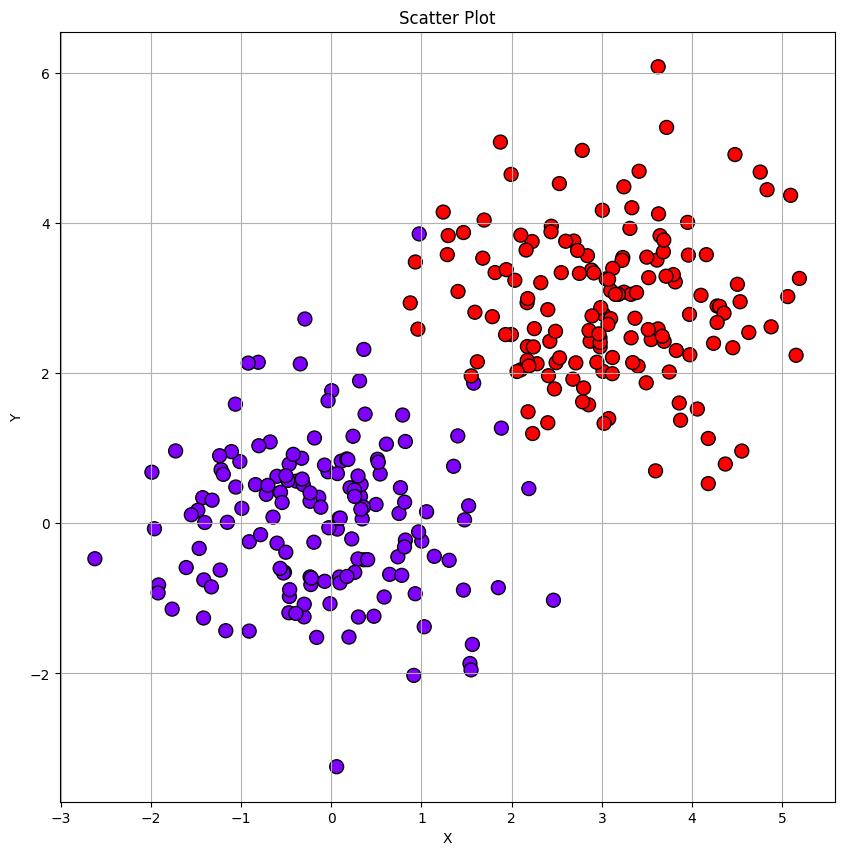

In [22]:
plt.figure(figsize = (10 , 10) , frameon = True)
plt.scatter(df['X'],df['Y'],c=df['class'] , cmap = 'rainbow' , s = 100 , edgecolor = 'k' , hatch = '0')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatter Plot')
plt.grid(True)
plt.show()



In [23]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [25]:
X.shape , y.shape

((300, 2), (300,))

In [24]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
from tensorflow.keras.layers import BatchNormalization

In [34]:
model1 = Sequential()

model1.add(Dense(128 , activation = 'relu' , input_dim = 2 ))
model1.add(Dense(128 , activation = 'relu'))
model1.add(Dense(1 , activation = 'sigmoid'))

model1.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model1.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [39]:
history = model1.fit(X ,y, batch_size = 256 , epochs = 100 , validation_split = 0.2, verbose = 1 , shuffle = True)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5542 - loss: 0.6661 - val_accuracy: 1.0000 - val_loss: 0.5013
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.6083 - loss: 0.6290 - val_accuracy: 1.0000 - val_loss: 0.4325
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.7000 - loss: 0.5956 - val_accuracy: 1.0000 - val_loss: 0.3725
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.7875 - loss: 0.5657 - val_accuracy: 1.0000 - val_loss: 0.3209
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.8000 - loss: 0.5391 - val_accuracy: 1.0000 - val_loss: 0.2779
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8083 - loss: 0.5154 - val_accuracy: 1.0000 - val_loss: 0.2429
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.8167 - loss: 0.4946 - val_accuracy: 1.0000 - val_loss: 0.2137
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.8167 - loss: 0.4759 - val_accuracy: 1.0000 - val_

In [40]:
model2 = Sequential()

model2.add(Dense(256,activation='relu',input_dim=2))
model2.add(BatchNormalization())
model2.add(Dense(128,activation='relu'))
model2.add(BatchNormalization())
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,329 (138.00 KB)

 Trainable params: 34,561 (135.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [43]:
model2.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [45]:
history2 = model2.fit(X ,y, batch_size = 256 , epochs = 200 , validation_split = 0.2, verbose = 1 , shuffle = True) 

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9917 - loss: 0.0178 - val_accuracy: 1.0000 - val_loss: 0.0690
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9917 - loss: 0.0177 - val_accuracy: 1.0000 - val_loss: 0.0681
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9917 - loss: 0.0176 - val_accuracy: 1.0000 - val_loss: 0.0672
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9917 - loss: 0.0176 - val_accuracy: 1.0000 - val_loss: 0.0663
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9917 - loss: 0.0175 - val_accuracy: 1.0000 - val_loss: 0.0655
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9917 - loss: 0.0174 - val_accuracy: 1.0000 - val_loss: 0.0646
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.9917 - loss: 0.0174 - val_accuracy: 1.0000 - val_loss: 0.0637
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9917 - loss: 0.0173 - val_accuracy: 1.0000 - va

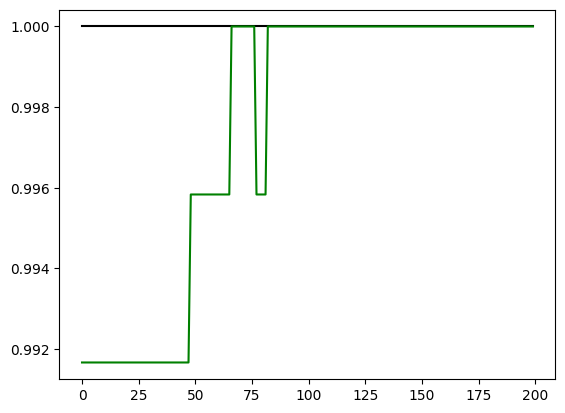

In [46]:
plt.plot(history2.history['val_accuracy'],color='black')
plt.plot(history2.history['accuracy'],color='green')

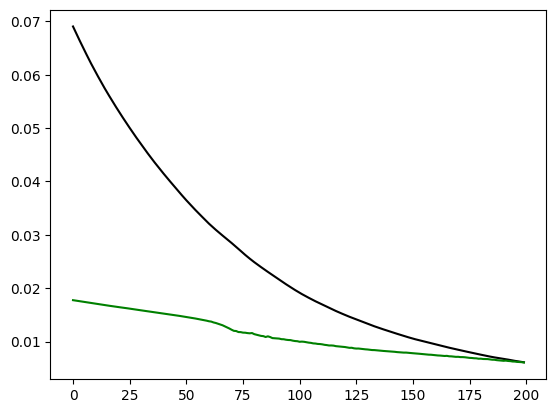

In [47]:
plt.plot(history2.history['val_loss'],color='black')
plt.plot(history2.history['loss'],color='green')

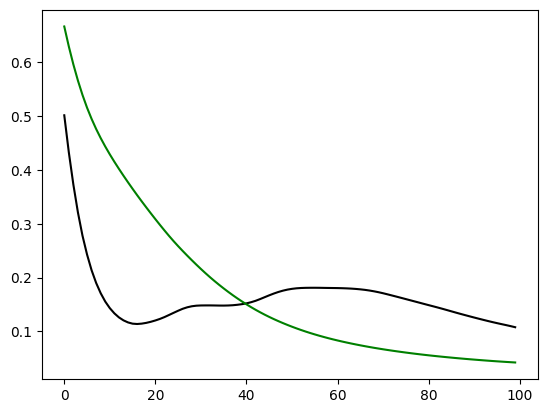

In [48]:
plt.plot(history.history['val_loss'],color='black')
plt.plot(history.history['loss'],color='green')

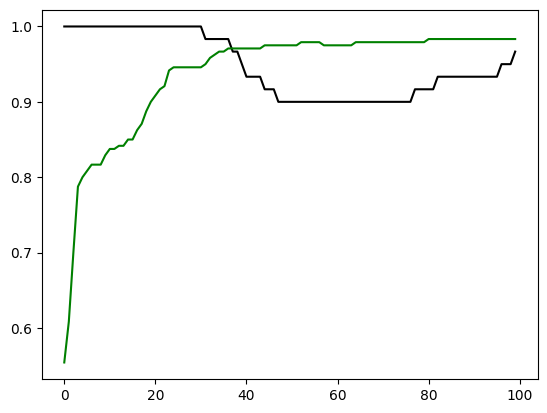

In [49]:
plt.plot(history.history['val_accuracy'],color='black')
plt.plot(history.history['accuracy'],color='green')